In [67]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *
from joblib import Parallel, delayed
from matplotlib.pyplot import imshow
import warnings
warnings.filterwarnings("ignore")
from scipy.optimize import curve_fit


In [198]:
Us = [kb.U(k,gi) for gi in gs]

rs = np.arange(0,40)
xxs=[]
for U in Us:
    xx = array([kb.sigma_general([0,ri],U,k) for ri in rs])-kb.sigma_general([0,90],U,k)
    xxs.append(xx)

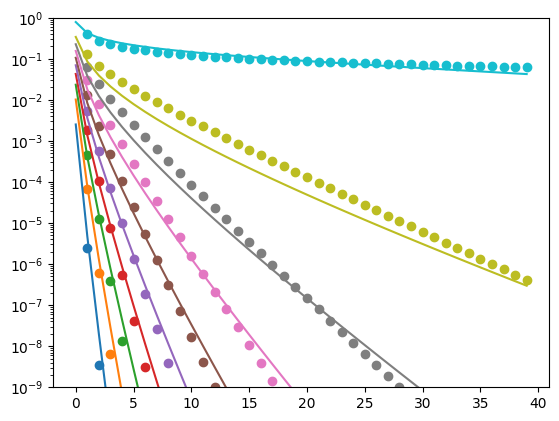

In [ ]:

for g,xx in zip(gs,xxs):
    plot(rs,xx)
    xi = 1/abs(log(g))
    scatter(rs,xx[0]*rs**(-1/2)/2*exp(-2.7*rs/xi))

ylim(10e-10,1)
yscale("log")

In [313]:
#Constants
L = 200
k = kb.k_vals(L)
ns = np.arange(1,13)
#Points both near and far from criticality
gs = np.linspace(.01,.5,15)
Us = [kb.U(k,gi) for gi in gs]

xis = 1/np.abs(log(gs))

taus = xis*xis
taus

array([0.04715292, 0.10398495, 0.15675688, 0.21377552, 0.27785   ,
       0.35120783, 0.43618926, 0.53553269, 0.6525997 , 0.79162846,
       0.95806431, 1.15901907, 1.40393147, 1.70554205, 2.08136898])

In [314]:

# compute dat for a single U
def compute_dat_for_U(U):
    return array([-log(kb.P_n(ni+1, U, k)/kb.P_n(ni,U,k)) for ni in ns])

In [315]:
# parallelize over Us
dat_all = Parallel(n_jobs=-1)(
    delayed(compute_dat_for_U)(U) for U in Us
)


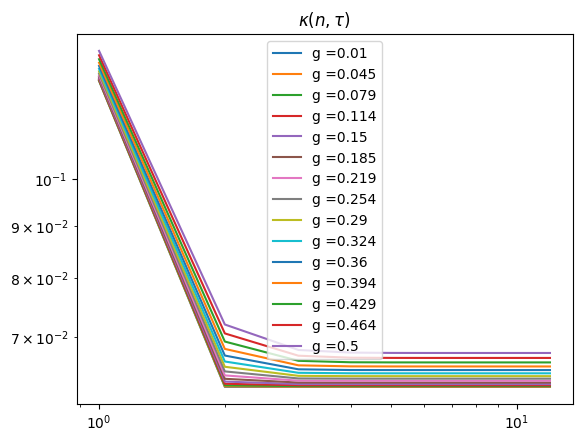

[]

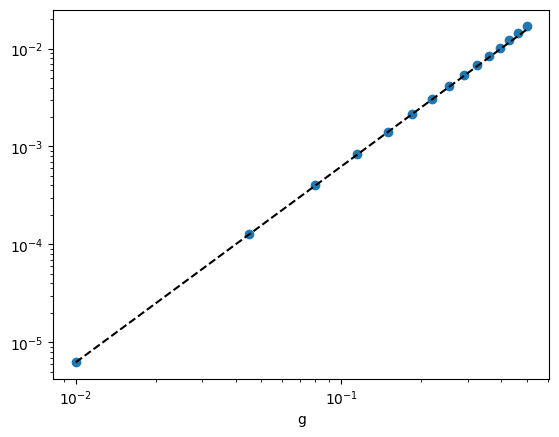

In [325]:
# example plot: all curves overlaid
dat2=[]
for dat,g,xi in zip(dat_all,gs,xis):
    xi = g**-1
    plot(ns,dat/(g*g),label=f"g ={str(g)[:5]}")
    dat2.append(dat[-1])
legend()
title(r"$\kappa(n,\tau)$")
loglog()
#xscale("log")
show()
scatter(gs,dat2)
plot(gs,gs**(2)/16,"--k")
xlabel("g")
loglog()

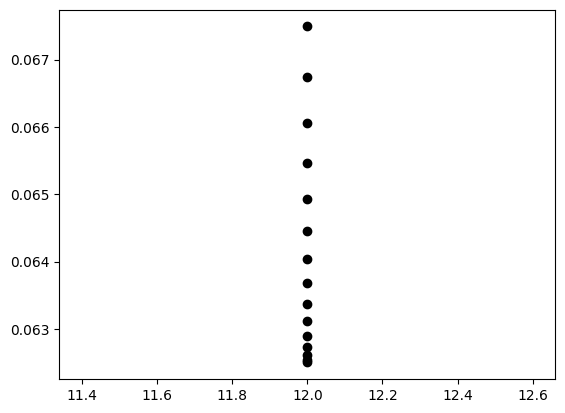

In [326]:
for dat,g in zip(dat_all,gs):
    scatter(ns[-1], dat[-1]/(g*g), c="k")


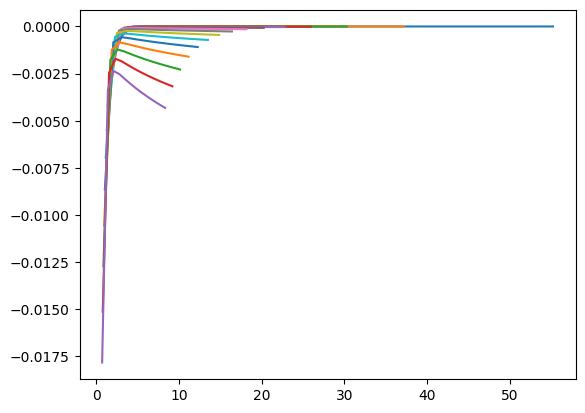

In [318]:
for dat,g,xi in zip(dat_all,gs,xis):
    k_inf = g**2/16
    plot(ns/xi, (k_inf-dat)*np.sqrt(ns), label=f"g={g:.3f}")


Text(0.5, 1.0, '$-\\log \\langle P^x_n \\rangle$')

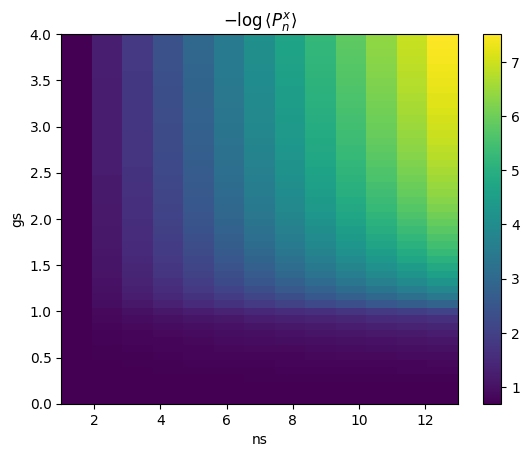

In [34]:
imshow(-np.real(np.log(dat_all)),origin="lower",extent=[ns[0],ns[-1],gs[0],gs[-1]],aspect="auto")
xlabel("ns")
ylabel("gs")
plt.colorbar()
title(r"$-\log \langle P^x_n \rangle$")
